In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns


## load the dataset 

In [12]:
df=pd.read_csv("C:/Users/Pratiksha Swami/Downloads/archive/traffic.csv")
df

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
...,...,...,...,...,...,...,...,...,...
226273,pageview,2021-08-24,Kuwait,Kuwait City,Sean Paul,The Trinity,Temperature,USAT20505520,04ba6b17-1055-4f0e-a75e-3cdb0d0d4106
226274,pageview,2021-08-24,India,Chennai,Miscél,when you left,when you left,QM42K1907890,2fc15e8b-83aa-40ee-9f9d-5d96c6d4356c
226275,pageview,2021-08-24,India,Jaipur,"Trippie Redd, Lil Uzi Vert",Holy Smokes (feat. Lil Uzi Vert),Holy Smokes,QZJ842001118,eedc8702-6bd2-499a-972f-260c35f72e0f
226276,pageview,2021-08-24,France,Unknown,Young Thug,Tick Tock,Tick Tock,USAT22104514,e0a76dc3-7ccd-405f-8ee8-a2c55c0e0ed2


## CLEANING DATA 

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    226278 non-null  object        
 1   date     226278 non-null  datetime64[ns]
 2   country  226267 non-null  object        
 3   city     226267 non-null  object        
 4   artist   226241 non-null  object        
 5   album    226273 non-null  object        
 6   track    226273 non-null  object        
 7   isrc     219157 non-null  object        
 8   linkid   226278 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 15.5+ MB


In [18]:
df['date']=pd.to_datetime(df['date'])

In [8]:
df.isnull().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

df.fillna('Unknown', inplace=True)

### KPI'S  Compute metrics: sessions, users, bounce rate, average session duration

In [13]:
total_sessions=df['linkid'].nunique()
print("Total Sessions :",total_sessions)

Total Sessions : 3839


In [14]:
session_counts=df.groupby('linkid').size()
bounce_sessions = session_counts[session_counts == 1].count()
bounce_rate = (bounce_sessions / total_sessions) * 100
print("Bounce Rate :", bounce_rate)

Bounce Rate : 34.01927585308674


In [33]:
# Step 1: count events per session
session_counts = df.groupby('linkid').size()

# Step 2: keep sessions with >1 event
valid_sessions = session_counts[session_counts > 1].index

filtered_df = df[df['linkid'].isin(valid_sessions)]

# Step 3: calculate duration
session_time = filtered_df.groupby('linkid')['date'].agg(['min','max'])

session_time['duration'] =( (
    session_time['max'] - session_time['min']
).dt.total_seconds() / 60)/60

# Step 4: average
avg_duration = session_time['duration'].mean()

print(f"Avg Session Duration: {avg_duration:.2f} Hours")

Avg Session Duration: 30.18 Hours


### Visualization 

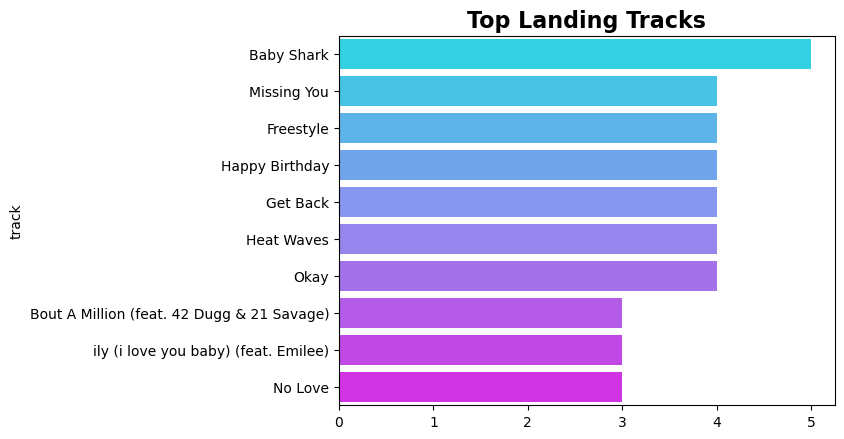

In [48]:
landing_pages = df.sort_values('date').groupby('linkid').first()

top_landing = landing_pages['track'].value_counts().head(10)

ax=sns.barplot(x=top_landing.values, y=top_landing.index,hue=top_landing.index,palette='cool')


    
plt.title("Top Landing Tracks",fontsize=16,fontweight='bold')
plt.show()

The landing track analysis shows that Baby Shark is the most common entry point for users, followed by tracks like Missing You and Freestyle. This indicates that a small set of popular tracks drives the majority of initial user engagement. These tracks act as key entry points into the platform and play a crucial role in attracting user attention.
Since top landing tracks attract the highest traffic, optimizing these tracks with recommendations, autoplay features, or personalized suggestions can significantly reduce bounce rates and improve user retention.

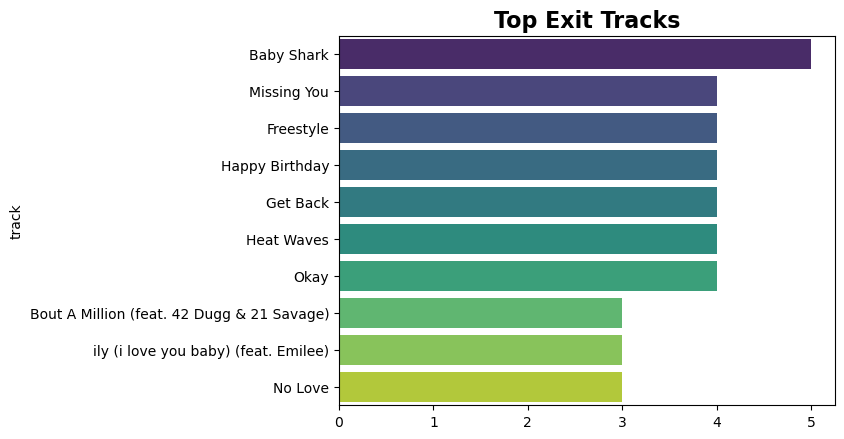

In [54]:
exit_pages = df.sort_values('date').groupby('linkid').last()

top_exit = exit_pages['track'].value_counts().head(10)

sns.barplot(x=top_exit.values, y=top_exit.index,hue=top_landing.index,palette='viridis')
plt.title("Top Exit Tracks",fontsize=16,fontweight='bold')
plt.show()


The exit track analysis reveals that Baby Shark is also the most common exit point, followed by tracks such as Missing You and Freestyle. This suggests that while these tracks successfully attract users, they may not effectively retain them for further interaction.

The overlap between top landing and exit tracks indicates a potential drop-off issue, where users leave the platform shortly after their initial interaction. This highlights an opportunity to improve content flow and engagement strategies.

C:\Users\Pratiksha Swami\AppData\Local\Temp\ipykernel_23172\3468834348.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=flow_df,x='Count',y='Transition',palette='coolwarm')


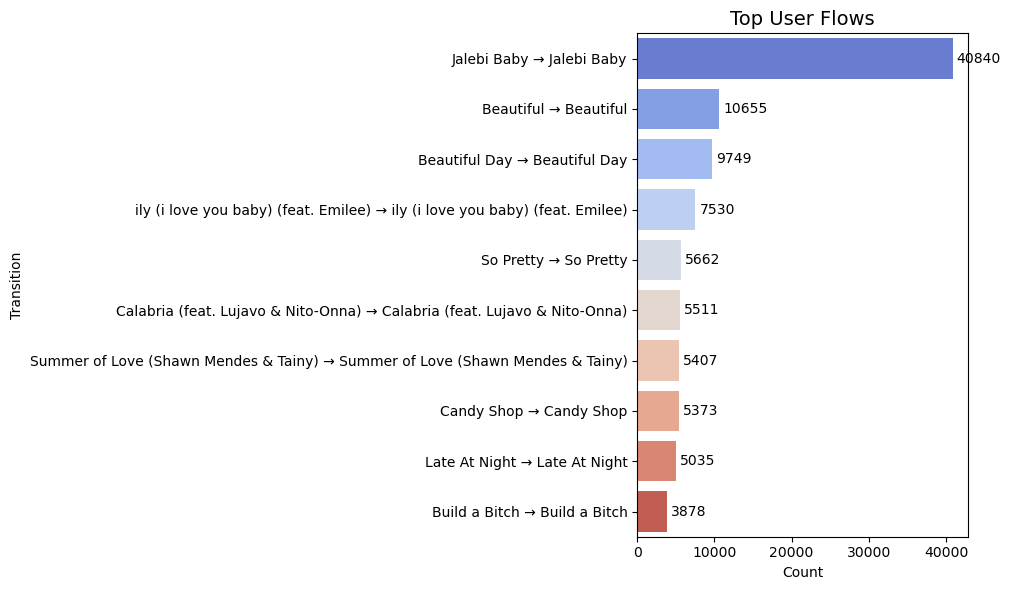

In [62]:
df_sorted = df.sort_values('date')

user_flow = df_sorted.groupby('linkid')['track'].apply(list)

from collections import Counter

transitions = []

for journey in user_flow:
    for i in range(len(journey)-1):
        transitions.append((journey[i], journey[i+1]))

top_transitions = Counter(transitions).most_common(10)

flow_df = pd.DataFrame(top_transitions, columns=['Transition', 'Count'])

flow_df['Transition'] = flow_df['Transition'].apply(lambda x: f"{x[0]} → {x[1]}")

plt.figure(figsize=(10,6))

ax = sns.barplot(data=flow_df,x='Count',y='Transition',palette='coolwarm')

# Add labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top User Flows", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Transition")

plt.tight_layout()
plt.show()

User flow analysis shows that the most frequent transitions occur within the same track (e.g., Jalebi Baby → Jalebi Baby), indicating repeated interactions or replay behavior. Other tracks also show similar patterns, suggesting that users tend to stay within the same content rather than exploring new tracks.


## Recommendations

1. Improve Landing Experience

Optimize top entry tracks by adding engaging elements like recommendations and autoplay features.

2. Reduce Bounce Rate

Encourage deeper interaction by suggesting related tracks or playlists immediately after entry.

3. Optimize Exit Points

Improve high-exit tracks by adding next-track suggestions or call-to-action elements.

4. Personalization

Use user behavior patterns to recommend tracks and improve engagement.

5. Enhance User Flow

Create seamless navigation through playlists and continuous playback to increase session duration.